In [6]:
import os, time, csv, math
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt

# ============================================================
# QWZ real-space model
# H(k) = -A sin(kx) sx - A sin(ky) sy + [u + t cos(kx) + t cos(ky)] sz
# Onsite impurity: V_imp = -h sz on impurity sites
# ============================================================

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
id2 = np.eye(2, dtype=complex)


def site_index(x, y, L):
    return x * L + y


def dof_index(x, y, orb, L):
    return 2 * site_index(x, y, L) + orb


def build_qwz_hamiltonian(L, u=-2.05, A=1.5, t=1.0, h=-1.0, impurities=None):
    """
    Dense real-space QWZ Hamiltonian on L x L torus.
    Dimension = 2 L^2.
    """
    Nsite = L * L
    dim = 2 * Nsite
    H = np.zeros((dim, dim), dtype=complex)

    impurities = set([] if impurities is None else impurities)

    onsite_clean = u * sz
    Tx = 0.5 * t * sz + 0.5j * A * sx
    Ty = 0.5 * t * sz + 0.5j * A * sy

    for x in range(L):
        for y in range(L):
            s = site_index(x, y, L)
            sl = slice(2*s, 2*s+2)

            onsite = onsite_clean.copy()
            if s in impurities:
                onsite = onsite - h * sz
            H[sl, sl] += onsite

            # +x hopping, periodic
            xp = (x + 1) % L
            sp = site_index(xp, y, L)
            slp = slice(2*sp, 2*sp+2)
            H[sl, slp] += Tx
            H[slp, sl] += Tx.conj().T

            # +y hopping, periodic
            yp = (y + 1) % L
            sp = site_index(x, yp, L)
            slp = slice(2*sp, 2*sp+2)
            H[sl, slp] += Ty
            H[slp, sl] += Ty.conj().T

    return H


def sample_impurities_fixed_density(L, nd=0.03, seed=0):
    """
    Fixed impurity number Nimp = round(nd * L^2).
    """
    rng = np.random.default_rng(seed)
    Nsite = L * L
    Nimp = int(round(nd * Nsite))
    return rng.choice(Nsite, size=Nimp, replace=False).astype(int)


def bott_index_from_eigensystem(evals, evecs, L, E_F=0.0):
    """
    Bott index using occupied subspace.
    We use projected position phase operators in the occupied space,
    then unitarize them by polar/SVD.
    """
    occ = evals < E_F
    psi = evecs[:, occ]
    nocc = psi.shape[1]

    if nocc == 0:
        return np.nan

    Nsite = L * L
    dim = 2 * Nsite

    x_coords = np.zeros(dim)
    y_coords = np.zeros(dim)

    for x in range(L):
        for y in range(L):
            s = site_index(x, y, L)
            for orb in range(2):
                idx = 2*s + orb
                x_coords[idx] = x
                y_coords[idx] = y

    phase_x = np.exp(2j * np.pi * x_coords / L)
    phase_y = np.exp(2j * np.pi * y_coords / L)

    # Occupied-space projected unitaries
    U = psi.conj().T @ (phase_x[:, None] * psi)
    V = psi.conj().T @ (phase_y[:, None] * psi)

    # Unitarize by polar decomposition via SVD
    Uu, _, Uvh = la.svd(U, full_matrices=False)
    Vu, _, Vvh = la.svd(V, full_matrices=False)
    Uunit = Uu @ Uvh
    Vunit = Vu @ Vvh

    W = Vunit @ Uunit @ Vunit.conj().T @ Uunit.conj().T
    eigW = la.eigvals(W)
    bott = np.sum(np.angle(eigW)) / (2*np.pi)

    return float(np.real_if_close(bott))


def impurity_mask_sites(L, impurities, radius=1.5):
    """
    Periodic-distance mask around impurity sites.
    radius=1.5 roughly includes impurity site plus nearest neighbors on square lattice.
    """
    impurities = np.array(list(impurities), dtype=int)
    mask = np.zeros(L*L, dtype=bool)

    imp_xy = []
    for s in impurities:
        x = s // L
        y = s % L
        imp_xy.append((x, y))

    for x in range(L):
        for y in range(L):
            inside = False
            for xi, yi in imp_xy:
                dx = min(abs(x - xi), L - abs(x - xi))
                dy = min(abs(y - yi), L - abs(y - yi))
                if math.sqrt(dx*dx + dy*dy) <= radius:
                    inside = True
                    break
            mask[site_index(x, y, L)] = inside

    return mask


def near_zero_observables(evals, evecs, L, impurities, mask_radius=1.5):
    """
    Compute:
    - finite-size spectral gap around E=0
    - near-zero eigenvalue
    - Wimp / fmask
    - L^2 IPR
    """
    # Gap around zero
    neg = evals[evals < 0]
    pos = evals[evals >= 0]
    if len(neg) > 0 and len(pos) > 0:
        gap = pos[0] - neg[-1]
    else:
        gap = np.nan

    iz = int(np.argmin(np.abs(evals)))
    ez = float(evals[iz])
    vec = evecs[:, iz]

    # site probability, summed over two orbitals
    p_site = np.zeros(L*L, dtype=float)
    for s in range(L*L):
        p_site[s] = np.abs(vec[2*s])**2 + np.abs(vec[2*s+1])**2

    ipr = float(np.sum(p_site**2))
    L2_ipr = float((L**2) * ipr)

    mask = impurity_mask_sites(L, impurities, radius=mask_radius)
    fmask = float(np.mean(mask))
    Wimp = float(np.sum(p_site[mask]))

    Wimp_over_fmask = Wimp / fmask if fmask > 0 else np.nan

    return {
        "gap": gap,
        "near_zero_E": ez,
        "Wimp": Wimp,
        "fmask": fmask,
        "Wimp_over_fmask": Wimp_over_fmask,
        "IPR": ipr,
        "L2IPR": L2_ipr,
    }


def run_one_sample(L, h, seed, params):
    impurities = sample_impurities_fixed_density(L, nd=params["nd"], seed=seed)

    H = build_qwz_hamiltonian(
        L=L,
        u=params["u"],
        A=params["A"],
        t=params["t"],
        h=h,
        impurities=impurities,
    )

    evals, evecs = la.eigh(H)
    B = bott_index_from_eigensystem(evals, evecs, L, E_F=params["E_F"])
    obs = near_zero_observables(
        evals, evecs, L, impurities, mask_radius=params["mask_radius"]
    )

    return B, obs

# Setup

In [4]:
# ============================================================
# Stage-2 Bott probability scan config
# ============================================================

params = {
    "u": -2.05,
    "A": 1.5,
    "t": 1.0,
    "nd": 0.03,
    "E_F": 0.0,
    "mask_radius": 1.5,
}

# 第一轮建议
# L_list = [16, 18, 20, 22, 24,]
L_list = [26, 28, 30, 32,]
n_samples = 100

# 两条 boundary 的精细窗口
left_h_values = np.round(np.arange(-3.49, -3.40 + 1e-12, 0.005), 6)
right_h_values = np.round(np.arange(-1.20, -1.08 + 1e-12, 0.005), 6)

scan_plan = {
    "left_impurity_boundary": left_h_values,
    "right_TAI_boundary": right_h_values,
}

base_seed = 20260710

# out_dir = "qwz_bott_stage1"
out_dir = "qwz_bott_stage2"
os.makedirs(out_dir, exist_ok=True)

raw_csv = os.path.join(out_dir, "qwz_bott_stage1_raw.csv")
summary_csv = os.path.join(out_dir, "qwz_bott_stage1_summary.csv")

print("Output folder:", out_dir)
print("Raw CSV:", raw_csv)
print("Summary CSV:", summary_csv)
print()
print("Parameters:", params)
print("L_list:", L_list)
print("n_samples:", n_samples)
print("left h points:", len(left_h_values), left_h_values[0], left_h_values[-1])
print("right h points:", len(right_h_values), right_h_values[0], right_h_values[-1])

Output folder: qwz_bott_stage2
Raw CSV: qwz_bott_stage2\qwz_bott_stage1_raw.csv
Summary CSV: qwz_bott_stage2\qwz_bott_stage1_summary.csv

Parameters: {'u': -2.05, 'A': 1.5, 't': 1.0, 'nd': 0.03, 'E_F': 0.0, 'mask_radius': 1.5}
L_list: [26, 28, 30, 32]
n_samples: 100
left h points: 19 -3.49 -3.4
right h points: 25 -1.2 -1.08


# Run

In [7]:
# ============================================================
# Long run with checkpointing
# ============================================================

raw_fields = [
    "boundary", "L", "h", "h_index", "sample", "seed",
    "Bott", "Bott_round", "absB_is_1",
    "gap", "near_zero_E",
    "Wimp", "fmask", "Wimp_over_fmask",
    "IPR", "L2IPR",
    "runtime_sec",
]

def load_done_keys(raw_csv):
    if not os.path.exists(raw_csv):
        return set()

    df_done = pd.read_csv(raw_csv)
    keys = set()
    for _, r in df_done.iterrows():
        keys.add((str(r["boundary"]), int(r["L"]), int(r["h_index"]), int(r["sample"])))
    return keys


def append_rows_to_csv(path, rows, fields):
    file_exists = os.path.exists(path)
    with open(path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        if not file_exists:
            writer.writeheader()
        for row in rows:
            writer.writerow(row)


def make_summary(raw_csv, summary_csv):
    if not os.path.exists(raw_csv):
        print("No raw CSV yet.")
        return None

    df = pd.read_csv(raw_csv)

    g = df.groupby(["boundary", "L", "h", "h_index"], as_index=False)
    summary = g.agg(
        n=("Bott", "count"),
        mean_B=("Bott", "mean"),
        std_B=("Bott", "std"),
        P_absB1=("absB_is_1", "mean"),
        mean_gap=("gap", "mean"),
        std_gap=("gap", "std"),
        mean_E0=("near_zero_E", "mean"),
        mean_Wimp_over_fmask=("Wimp_over_fmask", "mean"),
        std_Wimp_over_fmask=("Wimp_over_fmask", "std"),
        mean_L2IPR=("L2IPR", "mean"),
        std_L2IPR=("L2IPR", "std"),
        mean_runtime_sec=("runtime_sec", "mean"),
    )

    summary.to_csv(summary_csv, index=False)
    return summary


done_keys = load_done_keys(raw_csv)
print(f"Already completed samples: {len(done_keys)}")

t_global = time.time()

for L in L_list:
    print("\n" + "="*70)
    print(f"Starting L={L}")
    print("="*70)

    for boundary_name, h_values in scan_plan.items():
        boundary_offset = 0 if "left" in boundary_name else 500000000

        print(f"\n--- Boundary: {boundary_name}, h points = {len(h_values)} ---")

        for h_index, h in enumerate(h_values):
            point_t0 = time.time()
            rows = []

            # Check how many samples already done for this point
            already = sum(
                (boundary_name, L, h_index, s) in done_keys
                for s in range(n_samples)
            )

            if already >= n_samples:
                print(f"[skip] L={L:2d}, {boundary_name}, h={h:.6f}: already {already}/{n_samples}")
                continue

            print(f"[run ] L={L:2d}, {boundary_name}, h={h:.6f}: already {already}/{n_samples}")

            for sample in range(n_samples):
                key = (boundary_name, L, h_index, sample)
                if key in done_keys:
                    continue

                seed = int(base_seed + boundary_offset + 1000000*L + 1000*h_index + sample)

                t0 = time.time()
                try:
                    B, obs = run_one_sample(L=L, h=float(h), seed=seed, params=params)
                    runtime = time.time() - t0

                    B_round = int(np.round(B))
                    absB_is_1 = int(abs(B_round) == 1)

                    row = {
                        "boundary": boundary_name,
                        "L": L,
                        "h": float(h),
                        "h_index": h_index,
                        "sample": sample,
                        "seed": seed,
                        "Bott": B,
                        "Bott_round": B_round,
                        "absB_is_1": absB_is_1,
                        "gap": obs["gap"],
                        "near_zero_E": obs["near_zero_E"],
                        "Wimp": obs["Wimp"],
                        "fmask": obs["fmask"],
                        "Wimp_over_fmask": obs["Wimp_over_fmask"],
                        "IPR": obs["IPR"],
                        "L2IPR": obs["L2IPR"],
                        "runtime_sec": runtime,
                    }
                    rows.append(row)
                    done_keys.add(key)

                except Exception as e:
                    runtime = time.time() - t0
                    print(f"    ERROR: L={L}, h={h}, sample={sample}, seed={seed}, error={repr(e)}")

            # append after each (L,h) point
            if rows:
                append_rows_to_csv(raw_csv, rows, raw_fields)

            # update summary after each point
            summary = make_summary(raw_csv, summary_csv)

            point_dt = time.time() - point_t0
            if summary is not None:
                sub = summary[
                    (summary["boundary"] == boundary_name)
                    & (summary["L"] == L)
                    & (np.isclose(summary["h"], float(h)))
                ]
                if len(sub) > 0:
                    r = sub.iloc[0]
                    print(
                        f"    done n={int(r['n'])}, "
                        f"P_absB1={r['P_absB1']:.3f}, "
                        f"<B>={r['mean_B']:.3f}, "
                        f"gap={r['mean_gap']:.4g}, "
                        f"Wimp/fmask={r['mean_Wimp_over_fmask']:.3f}, "
                        f"L2IPR={r['mean_L2IPR']:.3f}, "
                        f"point time={point_dt/60:.2f} min"
                    )

print("\nAll requested runs finished or skipped.")
print(f"Total wall time: {(time.time() - t_global)/3600:.2f} hours")

summary = make_summary(raw_csv, summary_csv)
display(summary.head())

# # Quick plot
# if summary is not None:
#     for boundary_name in scan_plan.keys():
#         plt.figure(figsize=(7, 4), dpi=140)
#         subb = summary[summary["boundary"] == boundary_name]
#         for L in sorted(subb["L"].unique()):
#             ss = subb[subb["L"] == L].sort_values("h")
#             plt.plot(ss["h"], ss["P_absB1"], marker="o", label=f"L={L}")
#         plt.xlabel("h")
#         plt.ylabel(r"$P_{|B|=1}$")
#         plt.title(boundary_name)
#         plt.grid(alpha=0.3)
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

Already completed samples: 0

Starting L=26

--- Boundary: left_impurity_boundary, h points = 19 ---
[run ] L=26, left_impurity_boundary, h=-3.490000: already 0/100
    done n=100, P_absB1=0.000, <B>=-0.000, gap=0.02411, Wimp/fmask=3.284, L2IPR=11.274, point time=9.16 min
[run ] L=26, left_impurity_boundary, h=-3.485000: already 0/100
    done n=100, P_absB1=0.010, <B>=0.010, gap=0.02203, Wimp/fmask=3.275, L2IPR=11.201, point time=9.01 min
[run ] L=26, left_impurity_boundary, h=-3.480000: already 0/100
    done n=100, P_absB1=0.020, <B>=0.020, gap=0.0179, Wimp/fmask=3.279, L2IPR=11.565, point time=9.05 min
[run ] L=26, left_impurity_boundary, h=-3.475000: already 0/100
    done n=100, P_absB1=0.030, <B>=0.030, gap=0.0164, Wimp/fmask=3.264, L2IPR=11.101, point time=9.08 min
[run ] L=26, left_impurity_boundary, h=-3.470000: already 0/100
    done n=100, P_absB1=0.050, <B>=0.050, gap=0.0141, Wimp/fmask=3.286, L2IPR=11.417, point time=9.00 min
[run ] L=26, left_impurity_boundary, h=-3.4650

,boundary,L,h,h_index,n,mean_B,std_B,P_absB1,mean_gap,std_gap,mean_E0,mean_Wimp_over_fmask,std_Wimp_over_fmask,mean_L2IPR,std_L2IPR,mean_runtime_sec
0,left_impurity_boundary,26,-3.490,0,100,-1.163730e-15,4.695698e-15,0.00,0.024110,0.009744,-0.009195,3.283768,0.142343,11.273865,2.482726,5.497944
1,left_impurity_boundary,26,-3.485,1,100,1.000000e-02,1.000000e-01,0.01,0.022030,0.009329,-0.007650,3.275418,0.156740,11.201446,2.385932,5.406722
2,left_impurity_boundary,26,-3.480,2,100,2.000000e-02,1.407053e-01,0.02,0.017903,0.009083,-0.005685,3.279366,0.171482,11.564956,2.851550,5.427758
3,left_impurity_boundary,26,-3.475,3,100,3.000000e-02,1.714466e-01,0.03,0.016401,0.008807,-0.006280,3.263680,0.148518,11.101145,2.308757,5.448873
4,left_impurity_boundary,26,-3.470,4,100,5.000000e-02,2.190429e-01,0.05,0.014099,0.008900,-0.004714,3.285932,0.166521,11.416770,2.463401,5.397233


## Plotting & analysis

In [20]:
# ============================================================
# Cell 1
# Load Bott data and construct the finite-size density correction
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

out_dir = "qwz_bott_stage1"
SUMMARY_CSV = os.path.join(out_dir, "qwz_bott_stage1_summary.csv")

# Nominal density requested in the simulation
P_TARGET = 0.03

df = pd.read_csv(SUMMARY_CSV).copy()

# Optional size selection
# target_L_list = [16, 18, 20, 22, 24]
# df = df[df["L"].isin(target_L_list)].copy()

# ------------------------------------------------------------
# The simulation used
#
#     N_imp = round(p_target * L^2)
#
# so the actual finite-size density is generally not exactly
# equal to p_target.
# ------------------------------------------------------------

df["N_imp"] = df["L"].map(
    lambda L: int(round(P_TARGET * int(L) ** 2))
)

df["p_eff"] = (
    df["N_imp"]
    / df["L"].astype(float) ** 2
)

df["density_ratio"] = (
    df["p_eff"]
    / P_TARGET
)

# Equivalent impurity strength at exactly p_target:
#
#     p_eff * h = p_target * h_equiv
#
# hence
#
#     h_equiv = h * p_eff / p_target
#
# This coordinate is appropriate for the right TAI-like
# average-mass boundary, but not for the left impurity resonance.
df["h_equiv_p0"] = (
    df["h"]
    * df["density_ratio"]
)

print("Reading:", SUMMARY_CSV)
print("Using L:", sorted(df["L"].unique()))
print(f"Nominal target density p0 = {P_TARGET:.6f}")

print("\nActual finite-size impurity densities:")
density_table = (
    df[
        [
            "L",
            "N_imp",
            "p_eff",
            "density_ratio",
        ]
    ]
    .drop_duplicates()
    .sort_values("L")
)

print(
    density_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}",
    )
)

Reading: qwz_bott_stage1\qwz_bott_stage1_summary.csv
Using L: [np.int64(16), np.int64(18), np.int64(20), np.int64(22), np.int64(24)]
Nominal target density p0 = 0.030000

Actual finite-size impurity densities:
 L  N_imp      p_eff  density_ratio
16      8 0.03125000     1.04166667
18     10 0.03086420     1.02880658
20     12 0.03000000     1.00000000
22     15 0.03099174     1.03305785
24     17 0.02951389     0.98379630


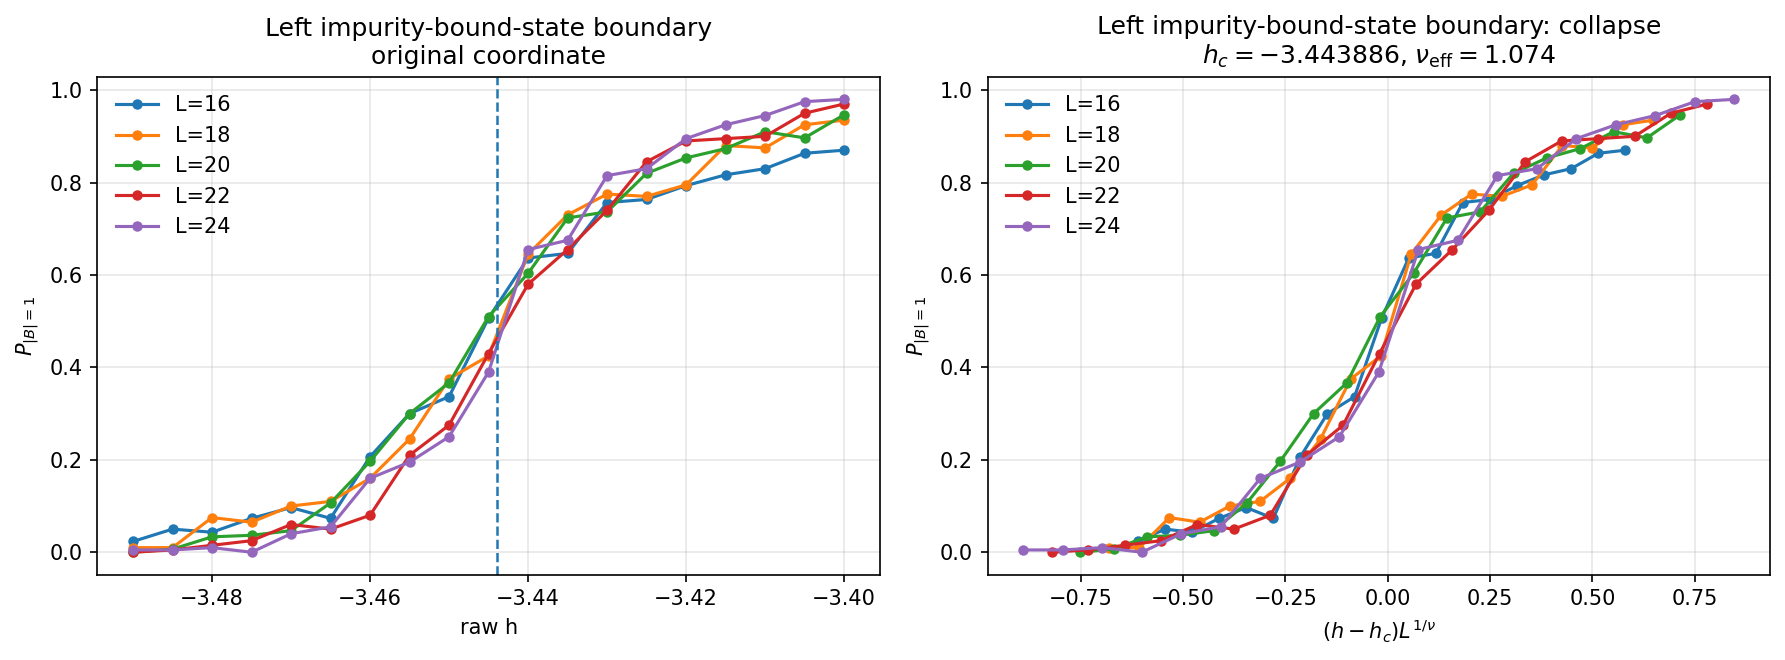


Left impurity-bound-state boundary
 L  N_imp      p_eff     h25_raw     h50_raw     h75_raw    h25_used    h50_used    h75_used  width_used
16      8 0.03125000 -3.45767857 -3.44519608 -3.43030303 -3.45767857 -3.44519608 -3.43030303  0.02737554
18     10 0.03086420 -3.45480769 -3.44329545 -3.43000000 -3.45480769 -3.44329545 -3.43000000  0.02480769
20     12 0.03000000 -3.45741935 -3.44534884 -3.42920000 -3.45741935 -3.44534884 -3.42920000  0.02821935
22     15 0.03099174 -3.45192308 -3.44266667 -3.42952381 -3.45192308 -3.44266667 -3.42952381  0.02239927
24     17 0.02951389 -3.45000000 -3.44292453 -3.43232143 -3.45000000 -3.44292453 -3.43232143  0.01767857

Analysis coordinate: h
Effective critical coordinate from mean h50: -3.44388631
Effective nu from width scaling: 1.0737
log(width) slope: -0.9314

Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.


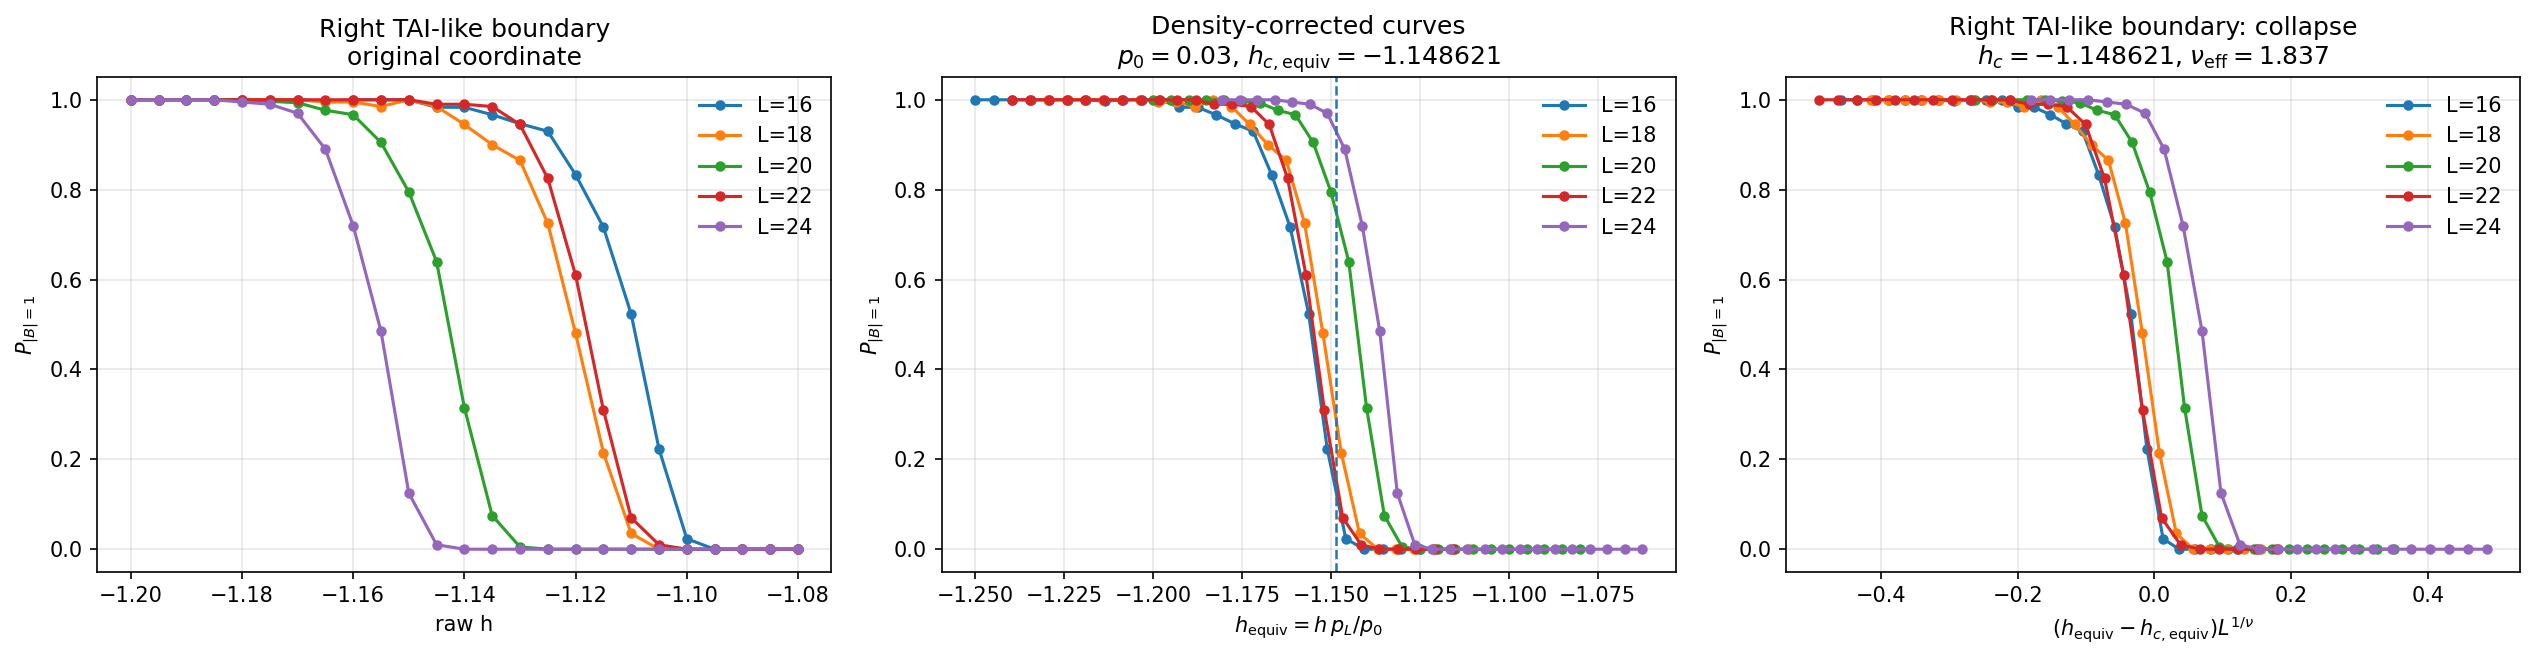


Right TAI-like boundary
 L  N_imp      p_eff     h25_raw     h50_raw     h75_raw    h25_used    h50_used    h75_used  width_used
16      8 0.03125000 -1.10544444 -1.10961111 -1.11642857 -1.15150463 -1.15584491 -1.16294643  0.01144180
18     10 0.03086420 -1.11566038 -1.12040816 -1.12589286 -1.14779874 -1.15268330 -1.15832598  0.01052724
20     12 0.03000000 -1.13864583 -1.14284615 -1.14854839 -1.13864583 -1.14284615 -1.14854839  0.00990255
22     15 0.03099174 -1.11375000 -1.11816667 -1.12325581 -1.15056818 -1.15513085 -1.16038824  0.00982006
24     17 0.02951389 -1.15173611 -1.15531915 -1.16088235 -1.13307372 -1.13659870 -1.14207176  0.00899804

Analysis coordinate: h_equiv_p0
Effective critical coordinate from mean h50: -1.14862078
Effective nu from width scaling: 1.8368
log(width) slope: -0.5444

std of raw h50 across L: 0.01904704
std of corrected h50 across L: 0.00849926
Correction used: h_equiv = h * p_eff / p_target

Reminder: this is a Bott-probability effective exponent, not 

In [21]:
# ============================================================
# Cell 2
# Width scaling and collapse
#
# Left boundary:
#     use raw h
#
# Right boundary:
#     use h_equiv = h * p_eff / p_target
# ============================================================


def interpolate_h_at_probability(h, probability, target_probability):
    """
    Interpolate the control coordinate where P = target_probability.

    The function works for both increasing and decreasing curves.
    This preserves the interpolation procedure used previously so
    that the only methodological change here is the density correction.
    """

    h = np.asarray(h, dtype=float)
    probability = np.asarray(probability, dtype=float)

    finite_mask = (
        np.isfinite(h)
        & np.isfinite(probability)
    )

    h = h[finite_mask]
    probability = probability[finite_mask]

    if len(h) < 2:
        return np.nan

    # Sort by the control coordinate
    order = np.argsort(h)
    h = h[order]
    probability = probability[order]

    # np.interp requires an increasing interpolation coordinate.
    # Reverse a decreasing transition.
    if probability[-1] < probability[0]:
        h = h[::-1]
        probability = probability[::-1]

    # Remove duplicate probability values
    probability_unique, unique_indices = np.unique(
        probability,
        return_index=True,
    )

    h_unique = h[unique_indices]

    if (
        target_probability < probability_unique.min()
        or target_probability > probability_unique.max()
    ):
        return np.nan

    return np.interp(
        target_probability,
        probability_unique,
        h_unique,
    )


def extract_widths_and_nu(
    summary_df,
    boundary_name,
    apply_density_correction=False,
):
    """
    For every L, extract:

        h25, h50, h75
        width = |h75 - h25|

    For the right TAI-like boundary, the analysis coordinate is

        h_equiv = h * p_eff / p_target.

    For the left impurity-bound-state boundary, the analysis
    coordinate remains the original h.

    The effective exponent is obtained from

        width ~ L^{-1/nu}.
    """

    rows = []

    sub = summary_df[
        summary_df["boundary"] == boundary_name
    ].copy()

    if sub.empty:
        raise ValueError(
            f"No data found for boundary={boundary_name!r}"
        )

    for L, ss in sub.groupby("L"):

        ss = ss.sort_values("h")

        probability = ss["P_absB1"].to_numpy(dtype=float)
        h_raw = ss["h"].to_numpy(dtype=float)

        if apply_density_correction:
            h_used = ss["h_equiv_p0"].to_numpy(dtype=float)
            analysis_coordinate = "h_equiv_p0"
        else:
            h_used = h_raw
            analysis_coordinate = "h"

        # Raw pseudocritical coordinates
        h25_raw = interpolate_h_at_probability(
            h_raw,
            probability,
            0.25,
        )

        h50_raw = interpolate_h_at_probability(
            h_raw,
            probability,
            0.50,
        )

        h75_raw = interpolate_h_at_probability(
            h_raw,
            probability,
            0.75,
        )

        # Coordinates actually used for scaling
        h25_used = interpolate_h_at_probability(
            h_used,
            probability,
            0.25,
        )

        h50_used = interpolate_h_at_probability(
            h_used,
            probability,
            0.50,
        )

        h75_used = interpolate_h_at_probability(
            h_used,
            probability,
            0.75,
        )

        width_used = abs(
            h75_used - h25_used
        )

        rows.append(
            {
                "L": int(L),
                "N_imp": int(ss["N_imp"].iloc[0]),
                "p_eff": float(ss["p_eff"].iloc[0]),

                "h25_raw": h25_raw,
                "h50_raw": h50_raw,
                "h75_raw": h75_raw,

                "h25_used": h25_used,
                "h50_used": h50_used,
                "h75_used": h75_used,

                "width_used": width_used,
            }
        )

    widths = (
        pd.DataFrame(rows)
        .sort_values("L")
        .reset_index(drop=True)
    )

    fit_data = widths[
        np.isfinite(widths["width_used"])
        & (widths["width_used"] > 0)
    ].copy()

    if len(fit_data) < 2:
        raise RuntimeError(
            "At least two valid system sizes are required."
        )

    log_L = np.log(
        fit_data["L"].to_numpy(dtype=float)
    )

    log_width = np.log(
        fit_data["width_used"].to_numpy(dtype=float)
    )

    slope, intercept = np.polyfit(
        log_L,
        log_width,
        1,
    )

    if slope >= 0:
        raise RuntimeError(
            "The fitted transition width does not decrease "
            f"with L. Fitted slope = {slope:.6f}"
        )

    nu_eff = -1.0 / slope

    hc_eff = float(
        np.nanmean(widths["h50_used"])
    )

    return (
        widths,
        nu_eff,
        hc_eff,
        slope,
        intercept,
        analysis_coordinate,
    )


def plot_boundary_collapse(
    summary_df,
    boundary_name,
    title_label,
    apply_density_correction=False,
):
    """
    Plot the original curves and the finite-size collapse.

    If density correction is enabled, an additional middle panel
    displays the curves after mapping every size to the common
    nominal density p0.
    """

    (
        widths,
        nu_eff,
        hc_eff,
        slope,
        intercept,
        analysis_coordinate,
    ) = extract_widths_and_nu(
        summary_df,
        boundary_name,
        apply_density_correction=apply_density_correction,
    )

    sub = summary_df[
        summary_df["boundary"] == boundary_name
    ].copy()

    if apply_density_correction:
        fig, axes = plt.subplots(
            1,
            3,
            figsize=(17, 4.5),
            dpi=150,
        )
    else:
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12, 4.5),
            dpi=150,
        )

    # ========================================================
    # Panel 1: original raw h coordinate
    # ========================================================

    ax = axes[0]

    for L, ss in sub.groupby("L"):

        ss = ss.sort_values("h")

        ax.plot(
            ss["h"],
            ss["P_absB1"],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"L={L}",
        )

    ax.set_xlabel("raw h")
    ax.set_ylabel(r"$P_{|B|=1}$")
    ax.set_title(
        f"{title_label}\n"
        "original coordinate"
    )
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    # ========================================================
    # Optional panel 2: corrected coordinate
    # ========================================================

    if apply_density_correction:

        ax = axes[1]

        for L, ss in sub.groupby("L"):

            ss = ss.sort_values("h_equiv_p0")

            ax.plot(
                ss["h_equiv_p0"],
                ss["P_absB1"],
                marker="o",
                linewidth=1.5,
                markersize=4,
                label=f"L={L}",
            )

        ax.axvline(
            hc_eff,
            linestyle="--",
            linewidth=1.2,
        )

        ax.set_xlabel(
            r"$h_{\mathrm{equiv}}"
            r"=h\,p_L/p_0$"
        )

        ax.set_ylabel(r"$P_{|B|=1}$")

        ax.set_title(
            "Density-corrected curves\n"
            + rf"$p_0={P_TARGET:g}$, "
            + rf"$h_{{c,\mathrm{{equiv}}}}={hc_eff:.6f}$"
        )

        ax.grid(alpha=0.3)
        ax.legend(frameon=False)

        collapse_ax = axes[2]

    else:

        axes[0].axvline(
            hc_eff,
            linestyle="--",
            linewidth=1.2,
        )

        collapse_ax = axes[1]

    # ========================================================
    # Final panel: finite-size collapse
    # ========================================================

    for L, ss in sub.groupby("L"):

        ss = ss.sort_values("h")

        if apply_density_correction:
            control_coordinate = ss[
                "h_equiv_p0"
            ].to_numpy(dtype=float)

            xlabel = (
                r"$(h_{\mathrm{equiv}}"
                r"-h_{c,\mathrm{equiv}})"
                r"L^{1/\nu}$"
            )

        else:
            control_coordinate = ss[
                "h"
            ].to_numpy(dtype=float)

            xlabel = (
                r"$(h-h_c)L^{1/\nu}$"
            )

        x_collapse = (
            control_coordinate - hc_eff
        ) * (
            float(L) ** (1.0 / nu_eff)
        )

        collapse_ax.plot(
            x_collapse,
            ss["P_absB1"],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"L={L}",
        )

    collapse_ax.set_xlabel(xlabel)
    collapse_ax.set_ylabel(r"$P_{|B|=1}$")

    collapse_ax.set_title(
        f"{title_label}: collapse\n"
        + rf"$h_c={hc_eff:.6f}$, "
        + rf"$\nu_{{\rm eff}}={nu_eff:.3f}$"
    )

    collapse_ax.grid(alpha=0.3)
    collapse_ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

    # ========================================================
    # Printed diagnostics
    # ========================================================

    print(f"\n{title_label}")
    print("=" * 110)

    print(
        widths.to_string(
            index=False,
            float_format=lambda x: f"{x:.8f}",
        )
    )

    print()
    print(
        "Analysis coordinate:",
        analysis_coordinate,
    )

    print(
        "Effective critical coordinate from mean h50:",
        f"{hc_eff:.8f}",
    )

    print(
        "Effective nu from width scaling:",
        f"{nu_eff:.4f}",
    )

    print(
        "log(width) slope:",
        f"{slope:.4f}",
    )

    if apply_density_correction:

        raw_h50_std = widths[
            "h50_raw"
        ].std(ddof=1)

        corrected_h50_std = widths[
            "h50_used"
        ].std(ddof=1)

        print()
        print(
            "std of raw h50 across L:",
            f"{raw_h50_std:.8f}",
        )

        print(
            "std of corrected h50 across L:",
            f"{corrected_h50_std:.8f}",
        )

        print(
            "Correction used: "
            "h_equiv = h * p_eff / p_target"
        )

    print()
    print(
        "Reminder: this is a Bott-probability effective "
        "exponent, not yet a transfer-matrix localization exponent."
    )

    return widths, nu_eff, hc_eff


# ============================================================
# Left boundary:
# no density correction
# ============================================================

left_widths, nu_left_eff, hc_left_eff = (
    plot_boundary_collapse(
        df,
        boundary_name="left_impurity_boundary",
        title_label=(
            "Left impurity-bound-state boundary"
        ),
        apply_density_correction=False,
    )
)


# ============================================================
# Right boundary:
# apply finite-size density correction
# ============================================================

right_widths, nu_right_eff, hc_right_eff = (
    plot_boundary_collapse(
        df,
        boundary_name="right_TAI_boundary",
        title_label="Right TAI-like boundary",
        apply_density_correction=True,
    )
)

Reading: qwz_bott_stage1\qwz_bott_stage1_summary.csv
Using L: [np.int64(16), np.int64(18), np.int64(20), np.int64(22), np.int64(24)]


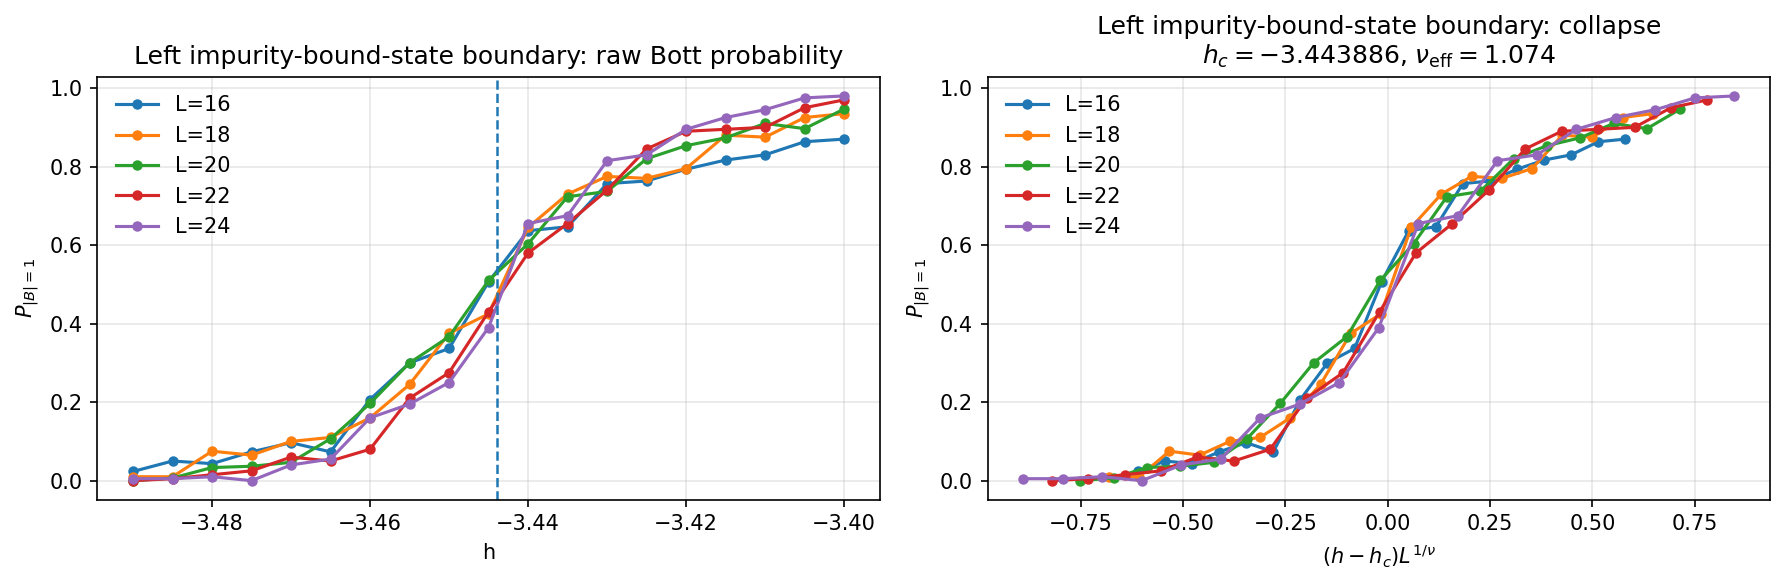


Left impurity-bound-state boundary
 L       h25       h50       h75    width
16 -3.457679 -3.445196 -3.430303 0.027376
18 -3.454808 -3.443295 -3.430000 0.024808
20 -3.457419 -3.445349 -3.429200 0.028219
22 -3.451923 -3.442667 -3.429524 0.022399
24 -3.450000 -3.442925 -3.432321 0.017679

Effective hc from mean h50: -3.44388631
Effective nu from width scaling: 1.0737
log(width) slope = -0.9314
Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.


In [7]:
import os
import pandas as pd

out_dir = "qwz_bott_stage1"
SUMMARY_CSV = os.path.join(out_dir, "qwz_bott_stage1_summary.csv")
df = pd.read_csv(SUMMARY_CSV)
# target_L_list = [16, 18, 20, 22, 24]
# df = df[df["L"].isin(target_L_list)].copy()

print("Reading:", SUMMARY_CSV)
print("Using L:", sorted(df["L"].unique()))

# =========================
# Helper functions
# =========================

def interpolate_h_at_probability(h, p, target_p):
    """
    Interpolate h where P(h)=target_p.
    Works for both increasing and decreasing P(h).
    """
    h = np.asarray(h, dtype=float)
    p = np.asarray(p, dtype=float)

    # Sort by h first
    idx = np.argsort(h)
    h = h[idx]
    p = p[idx]

    # If decreasing, reverse so p is roughly increasing
    if p[-1] < p[0]:
        h = h[::-1]
        p = p[::-1]

    # Remove duplicate probability values for stable interpolation
    p_unique, unique_idx = np.unique(p, return_index=True)
    h_unique = h[unique_idx]

    if target_p < p_unique.min() or target_p > p_unique.max():
        return np.nan

    return np.interp(target_p, p_unique, h_unique)


def extract_widths_and_nu(summary_df, boundary_name):
    """
    For each L:
        h25, h50, h75 from interpolation
        width = |h75 - h25|
    Then fit width ~ L^{-1/nu}.
    """
    rows = []

    sub = summary_df[summary_df["boundary"] == boundary_name].copy()

    for L, ss in sub.groupby("L"):
        ss = ss.sort_values("h")
        h = ss["h"].values
        p = ss["P_absB1"].values

        h25 = interpolate_h_at_probability(h, p, 0.25)
        h50 = interpolate_h_at_probability(h, p, 0.50)
        h75 = interpolate_h_at_probability(h, p, 0.75)

        width = abs(h75 - h25)

        rows.append({
            "L": int(L),
            "h25": h25,
            "h50": h50,
            "h75": h75,
            "width": width,
        })

    widths = pd.DataFrame(rows).sort_values("L")

    fit_data = widths.dropna()
    x = np.log(fit_data["L"].values)
    y = np.log(fit_data["width"].values)

    slope, intercept = np.polyfit(x, y, 1)
    nu_eff = -1.0 / slope

    hc_eff = np.nanmean(widths["h50"].values)

    return widths, nu_eff, hc_eff, slope, intercept


def plot_boundary_collapse(summary_df, boundary_name, title_label):
    widths, nu_eff, hc_eff, slope, intercept = extract_widths_and_nu(summary_df, boundary_name)

    sub = summary_df[summary_df["boundary"] == boundary_name].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

    # -------------------------
    # Left panel: raw data
    # -------------------------
    ax = axes[0]
    for L, ss in sub.groupby("L"):
        ss = ss.sort_values("h")
        ax.plot(
            ss["h"],
            ss["P_absB1"],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"L={L}"
        )

    ax.axvline(hc_eff, linestyle="--", linewidth=1.2)
    ax.set_xlabel("h")
    ax.set_ylabel(r"$P_{|B|=1}$")
    ax.set_title(f"{title_label}: raw Bott probability")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    # -------------------------
    # Right panel: collapsed data
    # -------------------------
    ax = axes[1]
    for L, ss in sub.groupby("L"):
        ss = ss.sort_values("h")
        xcollapse = (ss["h"].values - hc_eff) * (L ** (1.0 / nu_eff))
        ax.plot(
            xcollapse,
            ss["P_absB1"],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"L={L}"
        )

    ax.set_xlabel(r"$(h-h_c)L^{1/\nu}$")
    ax.set_ylabel(r"$P_{|B|=1}$")
    ax.set_title(
        f"{title_label}: collapse\n"
        + rf"$h_c={hc_eff:.6f}$, $\nu_{{\rm eff}}={nu_eff:.3f}$"
    )
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

    print(f"\n{title_label}")
    print("=" * 60)
    print(widths.to_string(index=False))
    print()
    print(f"Effective hc from mean h50: {hc_eff:.8f}")
    print(f"Effective nu from width scaling: {nu_eff:.4f}")
    print(f"log(width) slope = {slope:.4f}")
    print("Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.")

    return widths, nu_eff, hc_eff


# =========================
# Plot left boundary
# =========================

left_widths, nu_left_eff, hc_left_eff = plot_boundary_collapse(
    df,
    boundary_name="left_impurity_boundary",
    title_label="Left impurity-bound-state boundary"
)

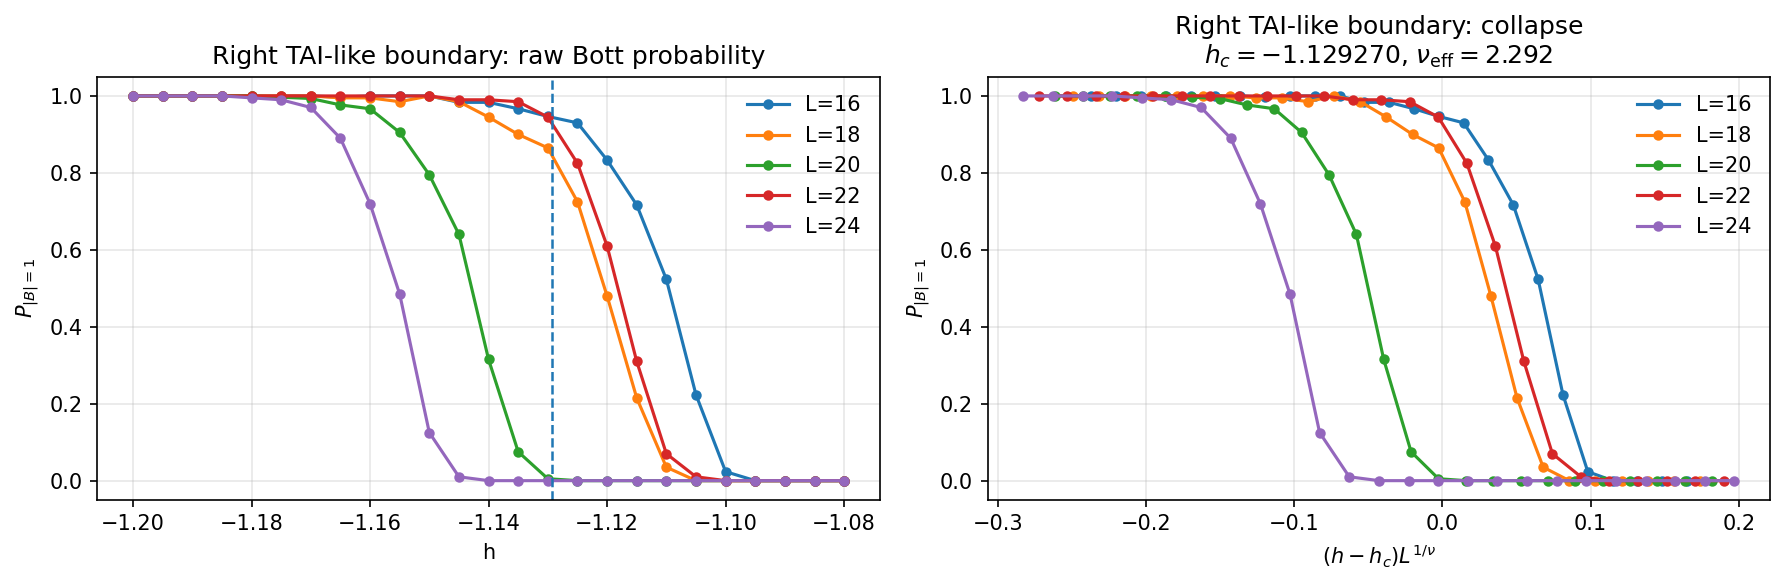


Right TAI-like boundary
 L       h25       h50       h75    width
16 -1.105444 -1.109611 -1.116429 0.010984
18 -1.115660 -1.120408 -1.125893 0.010232
20 -1.138646 -1.142846 -1.148548 0.009903
22 -1.113750 -1.118167 -1.123256 0.009506
24 -1.151736 -1.155319 -1.160882 0.009146

Effective hc from mean h50: -1.12927025
Effective nu from width scaling: 2.2923
log(width) slope = -0.4362
Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.


In [4]:
# =========================
# Plot right boundary
# =========================

right_widths, nu_right_eff, hc_right_eff = plot_boundary_collapse(
    df,
    boundary_name="right_TAI_boundary",
    title_label="Right TAI-like boundary"
)

Reading: qwz_bott_stage2\qwz_bott_stage1_summary.csv
Using L: [np.int64(26), np.int64(28), np.int64(30), np.int64(32)]


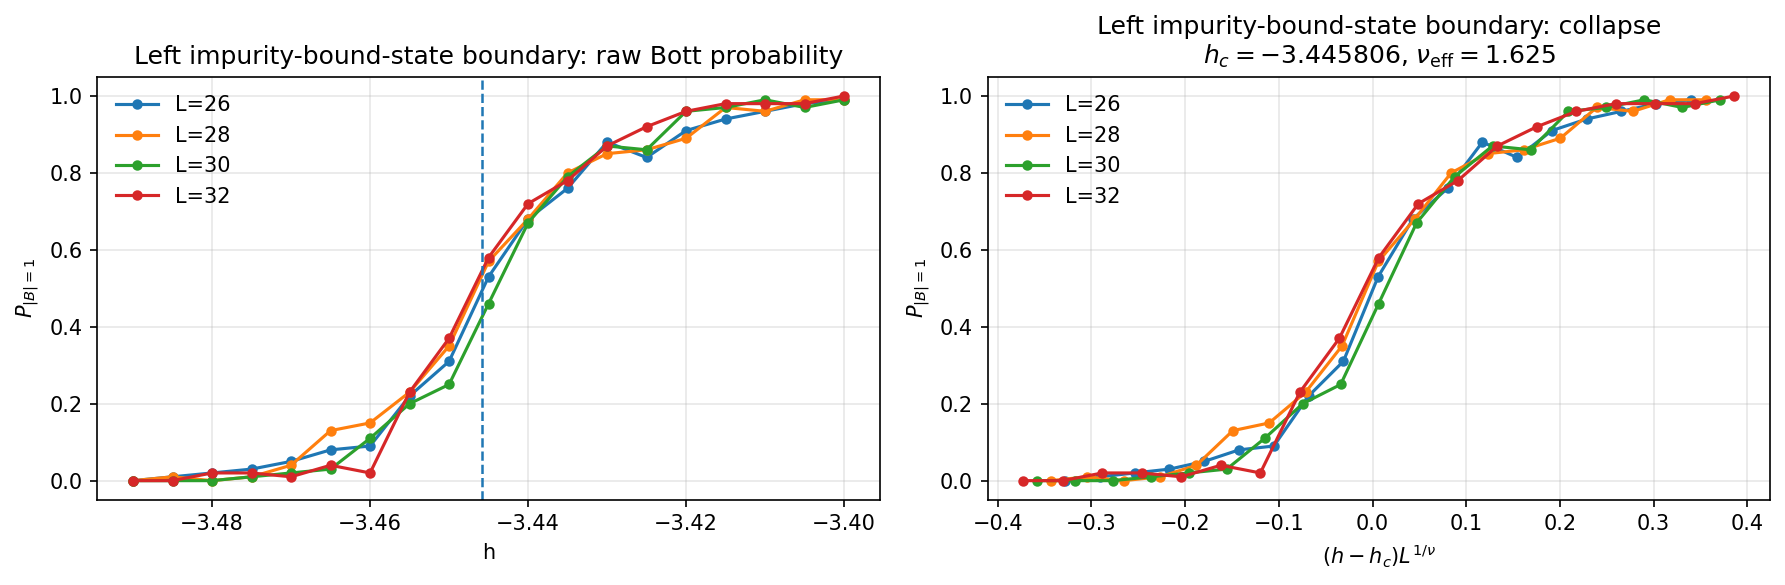


Left impurity-bound-state boundary
 L       h25       h50       h75    width
26 -3.453333 -3.445682 -3.435625 0.017708
28 -3.454167 -3.446591 -3.437083 0.017083
30 -3.450000 -3.444048 -3.436667 0.013333
32 -3.454286 -3.446905 -3.437500 0.016786

Effective hc from mean h50: -3.44580628
Effective nu from width scaling: 1.6254
log(width) slope = -0.6153
Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.


In [7]:
import os
import pandas as pd

out_dir = "qwz_bott_stage2"
SUMMARY_CSV = os.path.join(out_dir, "qwz_bott_stage1_summary.csv")
df = pd.read_csv(SUMMARY_CSV)
# target_L_list = [16, 18, 20, 22, 24]
# df = df[df["L"].isin(target_L_list)].copy()

print("Reading:", SUMMARY_CSV)
print("Using L:", sorted(df["L"].unique()))

# =========================
# Helper functions
# =========================

def interpolate_h_at_probability(h, p, target_p):
    """
    Interpolate h where P(h)=target_p.
    Works for both increasing and decreasing P(h).
    """
    h = np.asarray(h, dtype=float)
    p = np.asarray(p, dtype=float)

    # Sort by h first
    idx = np.argsort(h)
    h = h[idx]
    p = p[idx]

    # If decreasing, reverse so p is roughly increasing
    if p[-1] < p[0]:
        h = h[::-1]
        p = p[::-1]

    # Remove duplicate probability values for stable interpolation
    p_unique, unique_idx = np.unique(p, return_index=True)
    h_unique = h[unique_idx]

    if target_p < p_unique.min() or target_p > p_unique.max():
        return np.nan

    return np.interp(target_p, p_unique, h_unique)


def extract_widths_and_nu(summary_df, boundary_name):
    """
    For each L:
        h25, h50, h75 from interpolation
        width = |h75 - h25|
    Then fit width ~ L^{-1/nu}.
    """
    rows = []

    sub = summary_df[summary_df["boundary"] == boundary_name].copy()

    for L, ss in sub.groupby("L"):
        ss = ss.sort_values("h")
        h = ss["h"].values
        p = ss["P_absB1"].values

        h25 = interpolate_h_at_probability(h, p, 0.25)
        h50 = interpolate_h_at_probability(h, p, 0.50)
        h75 = interpolate_h_at_probability(h, p, 0.75)

        width = abs(h75 - h25)

        rows.append({
            "L": int(L),
            "h25": h25,
            "h50": h50,
            "h75": h75,
            "width": width,
        })

    widths = pd.DataFrame(rows).sort_values("L")

    fit_data = widths.dropna()
    x = np.log(fit_data["L"].values)
    y = np.log(fit_data["width"].values)

    slope, intercept = np.polyfit(x, y, 1)
    nu_eff = -1.0 / slope

    hc_eff = np.nanmean(widths["h50"].values)

    return widths, nu_eff, hc_eff, slope, intercept


def plot_boundary_collapse(summary_df, boundary_name, title_label):
    widths, nu_eff, hc_eff, slope, intercept = extract_widths_and_nu(summary_df, boundary_name)

    sub = summary_df[summary_df["boundary"] == boundary_name].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

    # -------------------------
    # Left panel: raw data
    # -------------------------
    ax = axes[0]
    for L, ss in sub.groupby("L"):
        ss = ss.sort_values("h")
        ax.plot(
            ss["h"],
            ss["P_absB1"],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"L={L}"
        )

    ax.axvline(hc_eff, linestyle="--", linewidth=1.2)
    ax.set_xlabel("h")
    ax.set_ylabel(r"$P_{|B|=1}$")
    ax.set_title(f"{title_label}: raw Bott probability")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    # -------------------------
    # Right panel: collapsed data
    # -------------------------
    ax = axes[1]
    for L, ss in sub.groupby("L"):
        ss = ss.sort_values("h")
        xcollapse = (ss["h"].values - hc_eff) * (L ** (1.0 / nu_eff))
        ax.plot(
            xcollapse,
            ss["P_absB1"],
            marker="o",
            linewidth=1.5,
            markersize=4,
            label=f"L={L}"
        )

    ax.set_xlabel(r"$(h-h_c)L^{1/\nu}$")
    ax.set_ylabel(r"$P_{|B|=1}$")
    ax.set_title(
        f"{title_label}: collapse\n"
        + rf"$h_c={hc_eff:.6f}$, $\nu_{{\rm eff}}={nu_eff:.3f}$"
    )
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

    print(f"\n{title_label}")
    print("=" * 60)
    print(widths.to_string(index=False))
    print()
    print(f"Effective hc from mean h50: {hc_eff:.8f}")
    print(f"Effective nu from width scaling: {nu_eff:.4f}")
    print(f"log(width) slope = {slope:.4f}")
    print("Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.")

    return widths, nu_eff, hc_eff


# =========================
# Plot left boundary
# =========================

left_widths, nu_left_eff, hc_left_eff = plot_boundary_collapse(
    df,
    boundary_name="left_impurity_boundary",
    title_label="Left impurity-bound-state boundary"
)

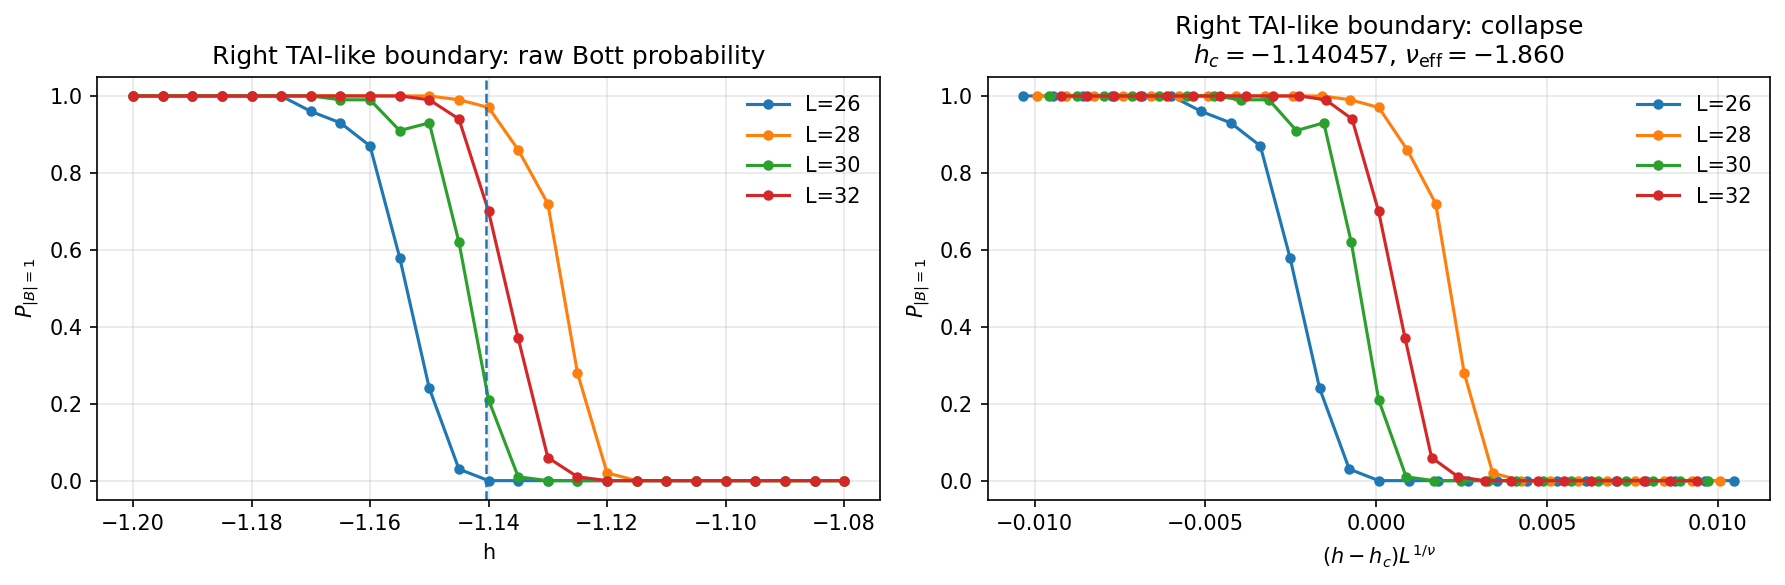


Right TAI-like boundary
 L       h25       h50       h75    width
26 -1.150147 -1.153824 -1.157931 0.007784
28 -1.124423 -1.127500 -1.131071 0.006648
30 -1.140488 -1.143537 -1.149483 0.008995
32 -1.133065 -1.136970 -1.141042 0.007977

Effective hc from mean h50: -1.14045745
Effective nu from width scaling: -1.8598
log(width) slope = 0.5377
Reminder: this is a Bott-probability effective exponent, not yet a transfer-matrix localization exponent.


In [9]:
# =========================
# Plot right boundary
# =========================

right_widths, nu_right_eff, hc_right_eff = plot_boundary_collapse(
    df,
    boundary_name="right_TAI_boundary",
    title_label="Right TAI-like boundary"
)

## Gaussian Smoother

[load] qwz_bott_stage1\qwz_bott_stage1_summary.csv, shape=(220, 17), L=[np.int64(16), np.int64(18), np.int64(20), np.int64(22), np.int64(24)]
[load] qwz_bott_stage2\qwz_bott_stage1_summary.csv, shape=(176, 17), L=[np.int64(26), np.int64(28), np.int64(30), np.int64(32)]

Combined data:
Boundary: left_impurity_boundary
L used: [np.int64(16), np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(26), np.int64(28), np.int64(30), np.int64(32)]
h range: -3.49 -3.4


,L,min,max,count
0,16,300,300,19
1,18,200,200,19
2,20,300,300,19
3,22,200,200,19
4,24,200,200,19
5,26,100,100,19
6,28,100,100,19
7,30,100,100,19
8,32,100,100,19



Smoothed h25/h50/h75 table:


,L,h25,h50,h75,width
0,16,-3.457059,-3.444670,-3.426958,0.030101
1,18,-3.455580,-3.443974,-3.430570,0.025009
2,20,-3.457333,-3.444891,-3.430184,0.027150
3,22,-3.452547,-3.442147,-3.429590,0.022957
4,24,-3.452288,-3.442616,-3.431748,0.020540
5,26,-3.453876,-3.445264,-3.435474,0.018402
6,28,-3.455231,-3.446191,-3.436115,0.019115
7,30,-3.452542,-3.443949,-3.435563,0.016979
8,32,-3.454177,-3.446615,-3.436744,0.017433



Best collapse from smoothed data:
hc_best = -3.44895946
nu_best = 1.100000
score   = 6.899765e-04

Trial exponents, with hc optimized for each fixed nu:


,nu,hc,score
0,1.000000,-3.448799,0.000700
1,1.333333,-3.449519,0.000721
2,2.400000,-3.452079,0.000965


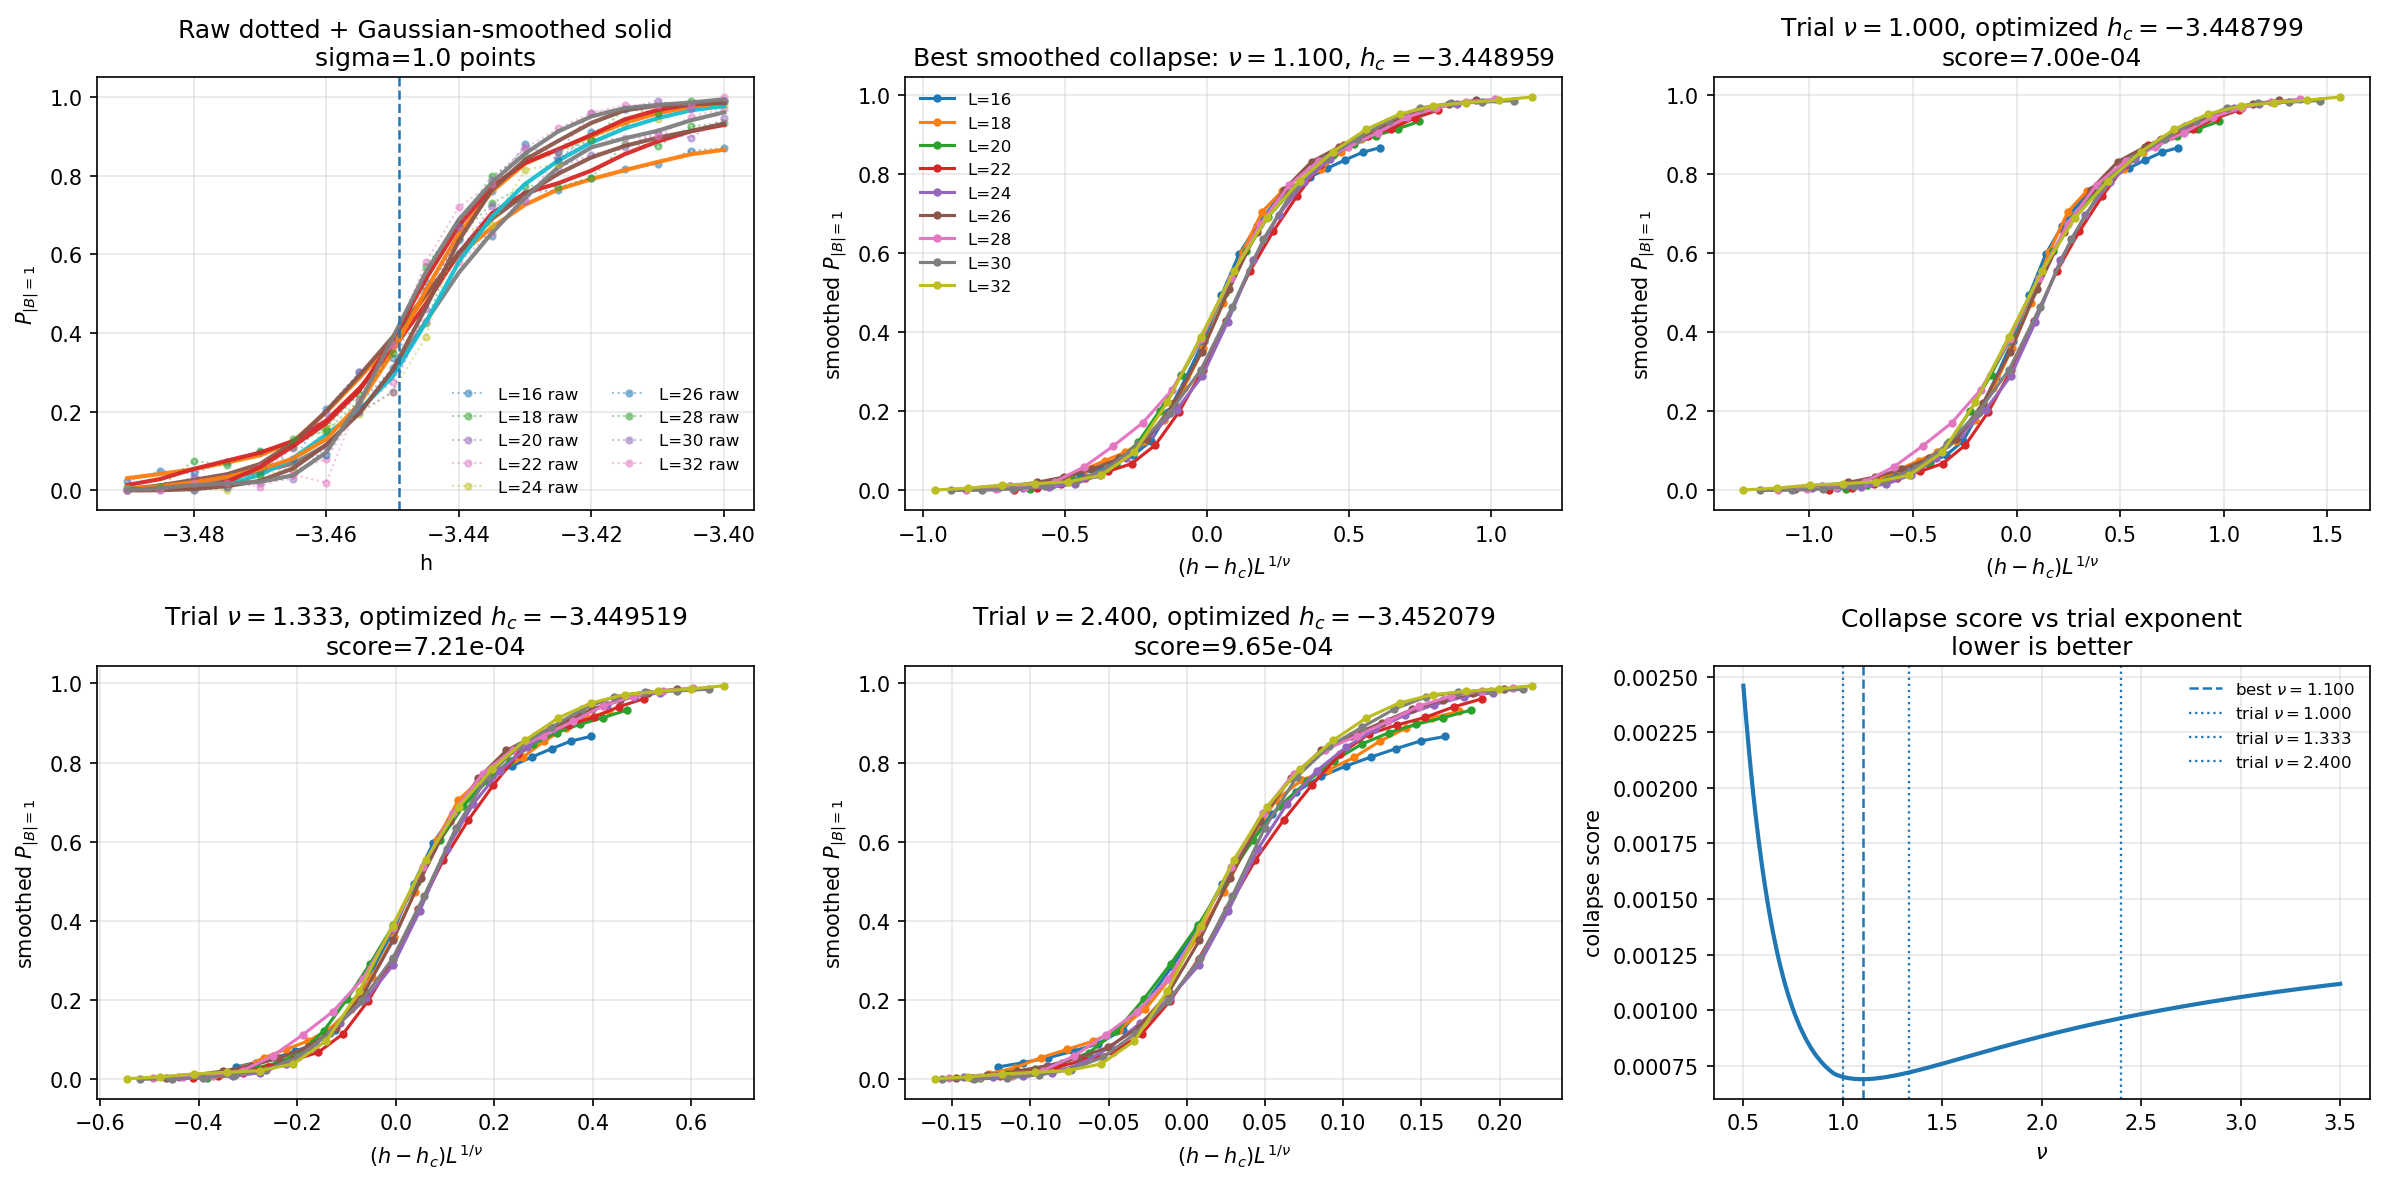


Saved combined smoothed data to: combined_left_boundary_smoothed_stage1_stage2.csv


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# User settings
# ============================================================

data_dirs = ["qwz_bott_stage1", "qwz_bott_stage2"]
summary_name = "qwz_bott_stage1_summary.csv"

target_boundary = "left_impurity_boundary"
target_L_list = None
# Example: target_L_list = [16, 18, 20, 22, 24, 26, 28, 30, 32]
# If None, use all L found in the combined data.

smooth_sigma_pts = 1.0
# Gaussian smoothing width in number of h-grid points.
# Try 0.75, 1.0, 1.25. Do not make it too large.

enforce_monotonic = True
# For the left boundary P increases from 0 to 1.
# This removes small non-monotonic wiggles after Gaussian smoothing.

nu_grid = np.linspace(0.5, 3.5, 301)
hc_grid_pad = 0.012
n_hc_grid = 301

trial_nus = [1.0, 4/3, 2.4]

# ============================================================
# Load and combine summary data
# ============================================================

dfs = []

for d in data_dirs:
    path = os.path.join(d, summary_name)
    if not os.path.exists(path):
        print(f"[skip] missing: {path}")
        continue

    tmp = pd.read_csv(path)
    tmp["source_dir"] = d
    dfs.append(tmp)
    print(f"[load] {path}, shape={tmp.shape}, L={sorted(tmp['L'].unique())}")

if len(dfs) == 0:
    raise FileNotFoundError("No summary CSV found in the requested data_dirs.")

df_all = pd.concat(dfs, ignore_index=True)

df = df_all[df_all["boundary"] == target_boundary].copy()

if target_L_list is not None:
    df = df[df["L"].isin(target_L_list)].copy()

# Weighted recombination in case the two folders overlap in L,h.
# This prevents duplicate rows from being plotted as separate datasets.
combine_cols = ["boundary", "L", "h", "h_index"]

def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if np.sum(weights) == 0:
        return np.nan
    return np.sum(values * weights) / np.sum(weights)

rows = []
for key, ss in df.groupby(combine_cols):
    n = ss["n"].values.astype(float)

    row = dict(zip(combine_cols, key))
    row["n"] = int(np.sum(n))

    for col in [
        "mean_B", "P_absB1", "mean_gap", "mean_E0",
        "mean_Wimp_over_fmask", "mean_L2IPR"
    ]:
        if col in ss.columns:
            row[col] = weighted_mean(ss[col].values, n)

    rows.append(row)

dfc = pd.DataFrame(rows).sort_values(["L", "h"]).reset_index(drop=True)

print("\nCombined data:")
print("Boundary:", target_boundary)
print("L used:", sorted(dfc["L"].unique()))
print("h range:", dfc["h"].min(), dfc["h"].max())
display(dfc.groupby("L")["n"].agg(["min", "max", "count"]).reset_index())

# ============================================================
# Smooth each L curve
# ============================================================

smooth_rows = []

for L, ss in dfc.groupby("L"):
    ss = ss.sort_values("h").copy()
    h = ss["h"].values
    p = ss["P_absB1"].values

    p_smooth = gaussian_filter1d(p, sigma=smooth_sigma_pts, mode="nearest")
    p_smooth = np.clip(p_smooth, 0.0, 1.0)

    if enforce_monotonic:
        # left boundary is increasing
        p_smooth = np.maximum.accumulate(p_smooth)
        p_smooth = np.clip(p_smooth, 0.0, 1.0)

    ss["P_smooth"] = p_smooth
    smooth_rows.append(ss)

dfsmooth = pd.concat(smooth_rows, ignore_index=True)

# ============================================================
# Helper functions for collapse score
# ============================================================

def interp_h_at_p(h, p, target):
    h = np.asarray(h, dtype=float)
    p = np.asarray(p, dtype=float)

    idx = np.argsort(h)
    h = h[idx]
    p = p[idx]

    # make increasing in p
    if p[-1] < p[0]:
        h = h[::-1]
        p = p[::-1]

    p_unique, unique_idx = np.unique(p, return_index=True)
    h_unique = h[unique_idx]

    if target < p_unique.min() or target > p_unique.max():
        return np.nan

    return np.interp(target, p_unique, h_unique)


def get_h50_table(data):
    rows = []
    for L, ss in data.groupby("L"):
        ss = ss.sort_values("h")
        h50 = interp_h_at_p(ss["h"].values, ss["P_smooth"].values, 0.5)
        h25 = interp_h_at_p(ss["h"].values, ss["P_smooth"].values, 0.25)
        h75 = interp_h_at_p(ss["h"].values, ss["P_smooth"].values, 0.75)
        rows.append({
            "L": int(L),
            "h25": h25,
            "h50": h50,
            "h75": h75,
            "width": abs(h75 - h25),
        })
    return pd.DataFrame(rows).sort_values("L")


def collapse_score(data, hc, nu, n_x=250, pmin=0.05, pmax=0.95):
    """
    Collapse score = mean variance among interpolated curves on common x overlap.
    Lower is better.
    Uses smoothed probability P_smooth.
    """
    curves = []

    for L, ss in data.groupby("L"):
        ss = ss.sort_values("h")
        h = ss["h"].values
        p = ss["P_smooth"].values

        # focus on useful transition region
        mask = (p >= pmin) & (p <= pmax)
        if np.sum(mask) < 4:
            continue

        x = (h[mask] - hc) * (L ** (1.0 / nu))
        y = p[mask]

        idx = np.argsort(x)
        x = x[idx]
        y = y[idx]

        # remove duplicate x
        x_unique, unique_idx = np.unique(x, return_index=True)
        y_unique = y[unique_idx]

        if len(x_unique) < 4:
            continue

        curves.append((x_unique, y_unique))

    if len(curves) < 3:
        return np.inf

    xmin = max(c[0].min() for c in curves)
    xmax = min(c[0].max() for c in curves)

    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax <= xmin:
        return np.inf

    xgrid = np.linspace(xmin, xmax, n_x)

    ys = []
    for x, y in curves:
        ys.append(np.interp(xgrid, x, y))

    Y = np.vstack(ys)

    # variance across L curves at fixed collapsed x
    var_x = np.var(Y, axis=0)

    return float(np.mean(var_x))


def find_best_collapse(data, nu_grid, hc_grid):
    best = {"score": np.inf, "nu": None, "hc": None}

    for nu in nu_grid:
        for hc in hc_grid:
            score = collapse_score(data, hc=hc, nu=nu)
            if score < best["score"]:
                best = {"score": score, "nu": float(nu), "hc": float(hc)}

    return best


def plot_collapse(ax, data, hc, nu, title):
    for L, ss in data.groupby("L"):
        ss = ss.sort_values("h")
        x = (ss["h"].values - hc) * (L ** (1.0 / nu))
        ax.plot(
            x, ss["P_smooth"].values,
            marker="o", linewidth=1.5, markersize=3,
            label=f"L={L}"
        )

    ax.set_xlabel(r"$(h-h_c)L^{1/\nu}$")
    ax.set_ylabel(r"smoothed $P_{|B|=1}$")
    ax.set_title(title)
    ax.grid(alpha=0.3)


# ============================================================
# Determine hc search window from smoothed h50
# ============================================================

h50_table = get_h50_table(dfsmooth)
hc_center = np.nanmean(h50_table["h50"].values)

hc_grid = np.linspace(hc_center - hc_grid_pad, hc_center + hc_grid_pad, n_hc_grid)

best = find_best_collapse(dfsmooth, nu_grid=nu_grid, hc_grid=hc_grid)

print("\nSmoothed h25/h50/h75 table:")
display(h50_table)

print("\nBest collapse from smoothed data:")
print(f"hc_best = {best['hc']:.8f}")
print(f"nu_best = {best['nu']:.6f}")
print(f"score   = {best['score']:.6e}")

# Scores for trial nus, optimizing hc for each fixed nu
trial_results = []
for nu in trial_nus:
    scores = np.array([collapse_score(dfsmooth, hc=hc, nu=nu) for hc in hc_grid])
    j = int(np.nanargmin(scores))
    trial_results.append({
        "nu": nu,
        "hc": float(hc_grid[j]),
        "score": float(scores[j])
    })

trial_df = pd.DataFrame(trial_results)
print("\nTrial exponents, with hc optimized for each fixed nu:")
display(trial_df)

# ============================================================
# Plot: raw + smoothed, best collapse, trial collapses
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 8), dpi=150)
axes = axes.ravel()

# Panel 0: raw and smoothed data
ax = axes[0]
for L, ss in dfsmooth.groupby("L"):
    ss = ss.sort_values("h")
    ax.plot(
        ss["h"], ss["P_absB1"],
        marker="o", linestyle=":", linewidth=1.0, markersize=3,
        alpha=0.45, label=f"L={L} raw"
    )
    ax.plot(
        ss["h"], ss["P_smooth"],
        linewidth=2.0, alpha=0.95
    )

ax.axvline(best["hc"], linestyle="--", linewidth=1.2)
ax.set_xlabel("h")
ax.set_ylabel(r"$P_{|B|=1}$")
ax.set_title(f"Raw dotted + Gaussian-smoothed solid\nsigma={smooth_sigma_pts} points")
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=8, ncol=2)

# Panel 1: best collapse
plot_collapse(
    axes[1], dfsmooth,
    hc=best["hc"], nu=best["nu"],
    title=rf"Best smoothed collapse: $\nu={best['nu']:.3f}$, $h_c={best['hc']:.6f}$"
)
axes[1].legend(frameon=False, fontsize=8)

# Panels 2-4: trial exponents
for ax, row in zip(axes[2:5], trial_results):
    nu = row["nu"]
    hc = row["hc"]
    score = row["score"]
    plot_collapse(
        ax, dfsmooth,
        hc=hc, nu=nu,
        title=rf"Trial $\nu={nu:.3f}$, optimized $h_c={hc:.6f}$" + "\n" + f"score={score:.2e}"
    )

# Panel 5: score vs nu, optimized over hc
ax = axes[5]
score_vs_nu = []
hc_best_vs_nu = []

for nu in nu_grid:
    scores = np.array([collapse_score(dfsmooth, hc=hc, nu=nu) for hc in hc_grid])
    j = int(np.nanargmin(scores))
    score_vs_nu.append(scores[j])
    hc_best_vs_nu.append(hc_grid[j])

score_vs_nu = np.array(score_vs_nu)

ax.plot(nu_grid, score_vs_nu, linewidth=2)
ax.axvline(best["nu"], linestyle="--", linewidth=1.2, label=rf"best $\nu={best['nu']:.3f}$")
for nu in trial_nus:
    ax.axvline(nu, linestyle=":", linewidth=1.1, label=rf"trial $\nu={nu:.3f}$")

ax.set_xlabel(r"$\nu$")
ax.set_ylabel("collapse score")
ax.set_title("Collapse score vs trial exponent\nlower is better")
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# Optional: save combined smoothed data
# ============================================================

combined_out = "combined_left_boundary_smoothed_stage1_stage2.csv"
dfsmooth.to_csv(combined_out, index=False)
print(f"\nSaved combined smoothed data to: {combined_out}")